## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import zipfile

In [4]:
import os

# List files to find the correct zip name
files = os.listdir('/content')
zip_files = [f for f in files if f.endswith('.zip')]

if zip_files:
    zip_path = os.path.join('/content', zip_files[0])
    print(f"Extracting: {zip_path}")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("/content/dataset")
else:
    print("No zip file found in /content. Please ensure the file is uploaded.")

Extracting: /content/What_a_Waste_3.0_COUNTRY_Dataset_&_Codebook-Codebook,What_a_Waste_3.0_COUNTRY_Dataset_&_Codeboo[...].zip


In [5]:
extracted_path = "/content/dataset"
extracted_files = []

for root, dirs, files in os.walk(extracted_path):
    for file in files:
        extracted_files.append(os.path.join(root, file))

print("Extracted files:")
for f in extracted_files:
    print(f)

Extracted files:
/content/dataset/What_a_Waste_3.0_COUNTRY_Dataset_&_Codebook-Country dataset.csv
/content/dataset/What_a_Waste_3.0_COUNTRY_Dataset_&_Codebook-Lists lookup.csv
/content/dataset/What_a_Waste_3.0_COUNTRY_Dataset_&_Codebook-EPR Input sheet.csv
/content/dataset/What_a_Waste_3.0_COUNTRY_Dataset_&_Codebook-Info.csv
/content/dataset/What_a_Waste_3.0_COUNTRY_Dataset_&_Codebook-Codebook.csv


## Read the main Dataset

In [9]:
df = pd.read_csv("/content/dataset/What_a_Waste_3.0_COUNTRY_Dataset_&_Codebook-Country dataset.csv")

## View the Dataset

In [10]:
df.head()

,Country code,Region,Country name,Income group (waste generation year),Income group (2022),GDP,Population in waste generation year,MSW generation - year reported,MSW generation (t/y),MSW generation - point of measurement,...,Existence of EPR system for waste batteries,Existence of EPR system for other waste,EPR leadership model (private or government led),Mandatory or voluntary EPR,Operational status of EPR system,Existence of DRS for beverage containers,Geographical scope of DRS,DRS container scope,Driver of participation in DRS,Operational status of DRS
0,iso3c,region_id,country_name,income_id,income_id_2022,gdp,population_number_of_people,msw_total_msw_generation_year,msw_total_msw_generated_tonnes_year,msw_total_msw_generated_point_of_measurement,...,epr_(3)_batteries,epr_(6)_other,epr_Private_(industry_led)_or_public_(governme...,epr_mandatory_or_voluntary_scheme,epr_Operational_status,drs_for_beverage_containers_present,drs_geographical_scope,drs_containers_types,drs_mandatory_vs_voluntary,drs_operational_status
1,AFG,S. Asia,Afghanistan,LIC,LIC,"18,753,456,498","35,174,083",2017,"4,148,162",Not stated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ALB,Eur. & Cent. Asia,Albania,UMIC,UMIC,"18,032,009,220","2,865,704",2021,"754,094","Point of treatment or disposal (Landfill, dump...",...,Yes,Yes,Industry-led,Mandatory,Legally-binding regulations in place,NaN,NaN,NaN,NaN,NaN
3,DZA,Mid. East & N. Africa,Algeria,LMIC,LMIC,"164,873,415,325","43,685,420",2020,"13,500,000",Not stated,...,NaN,NaN,NaN,Both,Legally-binding regulations in place,NaN,NaN,NaN,NaN,NaN
4,ASM,E. Asia & Pacific,American Samoa,UMIC,HIC,"647,000,000","50,563",2019,"17,348",Not stated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.shape

(218, 110)

In [12]:
df.columns

Index(['Country code', 'Region', 'Country name ',
       'Income group (waste generation year)', 'Income group (2022)', 'GDP',
       'Population in waste generation year', 'MSW generation - year reported',
       'MSW generation (t/y)', 'MSW generation - point of measurement',
       ...
       'Existence of EPR system for waste batteries',
       'Existence of EPR system for other waste',
       'EPR leadership model (private or government led)',
       'Mandatory or voluntary EPR', 'Operational status of EPR system',
       'Existence of DRS for beverage containers', 'Geographical scope of DRS',
       'DRS container scope', 'Driver of participation in DRS',
       'Operational status of DRS'],
      dtype='object', length=110)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Columns: 110 entries, Country code to Operational status of DRS
dtypes: object(110)
memory usage: 187.5+ KB


In [14]:
#Statistical Summary
df.describe()

,Country code,Region,Country name,Income group (waste generation year),Income group (2022),GDP,Population in waste generation year,MSW generation - year reported,MSW generation (t/y),MSW generation - point of measurement,...,Existence of EPR system for waste batteries,Existence of EPR system for other waste,EPR leadership model (private or government led),Mandatory or voluntary EPR,Operational status of EPR system,Existence of DRS for beverage containers,Geographical scope of DRS,DRS container scope,Driver of participation in DRS,Operational status of DRS
count,218,218,218,202,218,202,218,202,218,201,...,68,90,144,145,146,55,55,55,55,55
unique,218,8,218,6,6,199,218,15,202,8,...,2,2,5,6,5,2,5,8,5,5
top,iso3c,Eur. & Cent. Asia,country_name,HIC,HIC,—,population_number_of_people,2022,—,Not stated,...,Yes,Yes,Industry-led,Mandatory,Legally-binding regulations in place,Yes,National,"Plastic, cans, and glass",Mandatory,Legally-binding regulations in place
freq,1,58,1,80,83,4,1,66,16,150,...,67,89,69,85,85,54,44,24,40,38


## Check Missing Values

In [15]:
df.isnull().sum()

,0
Country code,0
Region,0
Country name,0
Income group (waste generation year),16
Income group (2022),0
...,...
Existence of DRS for beverage containers,163
Geographical scope of DRS,163
DRS container scope,163
Driver of participation in DRS,163


## Duplicate Records

In [16]:
df.duplicated().sum()
#If duplicates exist,
df = df.drop_duplicates()

#Understand the Dataset

In [17]:
df.columns.tolist()

['Country code',
 'Region',
 'Country name ',
 'Income group (waste generation year)',
 'Income group (2022)',
 'GDP',
 'Population in waste generation year',
 'MSW generation - year reported',
 'MSW generation (t/y)',
 'MSW generation - point of measurement',
 'MSW generation (kg/capita/day)',
 'MSW generation - projected 2022 (t/year)',
 'Population in 2022',
 'MSW generation - projected 2022 (kg/cap/day)',
 'MSW generation - projected 2030 (t/y)',
 'Population in 2030',
 'MSW generation - projected 2030 (kg/cap/day)',
 'MSW generation - projected 2040 (t/y)',
 'Population in 2040',
 'MSW generation - projected 2040 (kg/cap/day)',
 'MSW generation - projected 2050 (t/y)',
 'Population in 2050',
 'MSW generation - projected 2050 (kg/cap/day)',
 'Composition - food  (% weight MSW)',
 'Composition - glass  (% weight MSW)',
 'Composition - metal (% weight MSW)',
 'Composition - paper & cardboard (% weight MSW)',
 'Composition - plastic (% weight MSW)',
 'Composition - rubber & leather  (

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Columns: 110 entries, Country code to Operational status of DRS
dtypes: object(110)
memory usage: 187.5+ KB


In [19]:
# Display all column names
for col in df.columns:
    print(col)

Country code
Region
Country name 
Income group (waste generation year)
Income group (2022)
GDP
Population in waste generation year
MSW generation - year reported
MSW generation (t/y)
MSW generation - point of measurement
MSW generation (kg/capita/day)
MSW generation - projected 2022 (t/year)
Population in 2022
MSW generation - projected 2022 (kg/cap/day)
MSW generation - projected 2030 (t/y)
Population in 2030
MSW generation - projected 2030 (kg/cap/day)
MSW generation - projected 2040 (t/y)
Population in 2040
MSW generation - projected 2040 (kg/cap/day)
MSW generation - projected 2050 (t/y)
Population in 2050
MSW generation - projected 2050 (kg/cap/day)
Composition - food  (% weight MSW)
Composition - glass  (% weight MSW)
Composition - metal (% weight MSW)
Composition - paper & cardboard (% weight MSW)
Composition - plastic (% weight MSW)
Composition - rubber & leather  (% weight MSW) 
Composition - wood (% weight MSW)
Composition - garden/green/horticultural (% weight MSW)
Compositi

In [21]:
# Show only numerical columns
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
print(numeric_columns)

Index([], dtype='object')


## Check Missing Values in Numerical Columns

In [22]:
df[numeric_columns].isnull().sum().sort_values(ascending=False)

,0


## Handle Missing Values

In [23]:
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())
#Verify
df[numeric_columns].isnull().sum()

,0


# Exploratory Data Analysis (EDA)

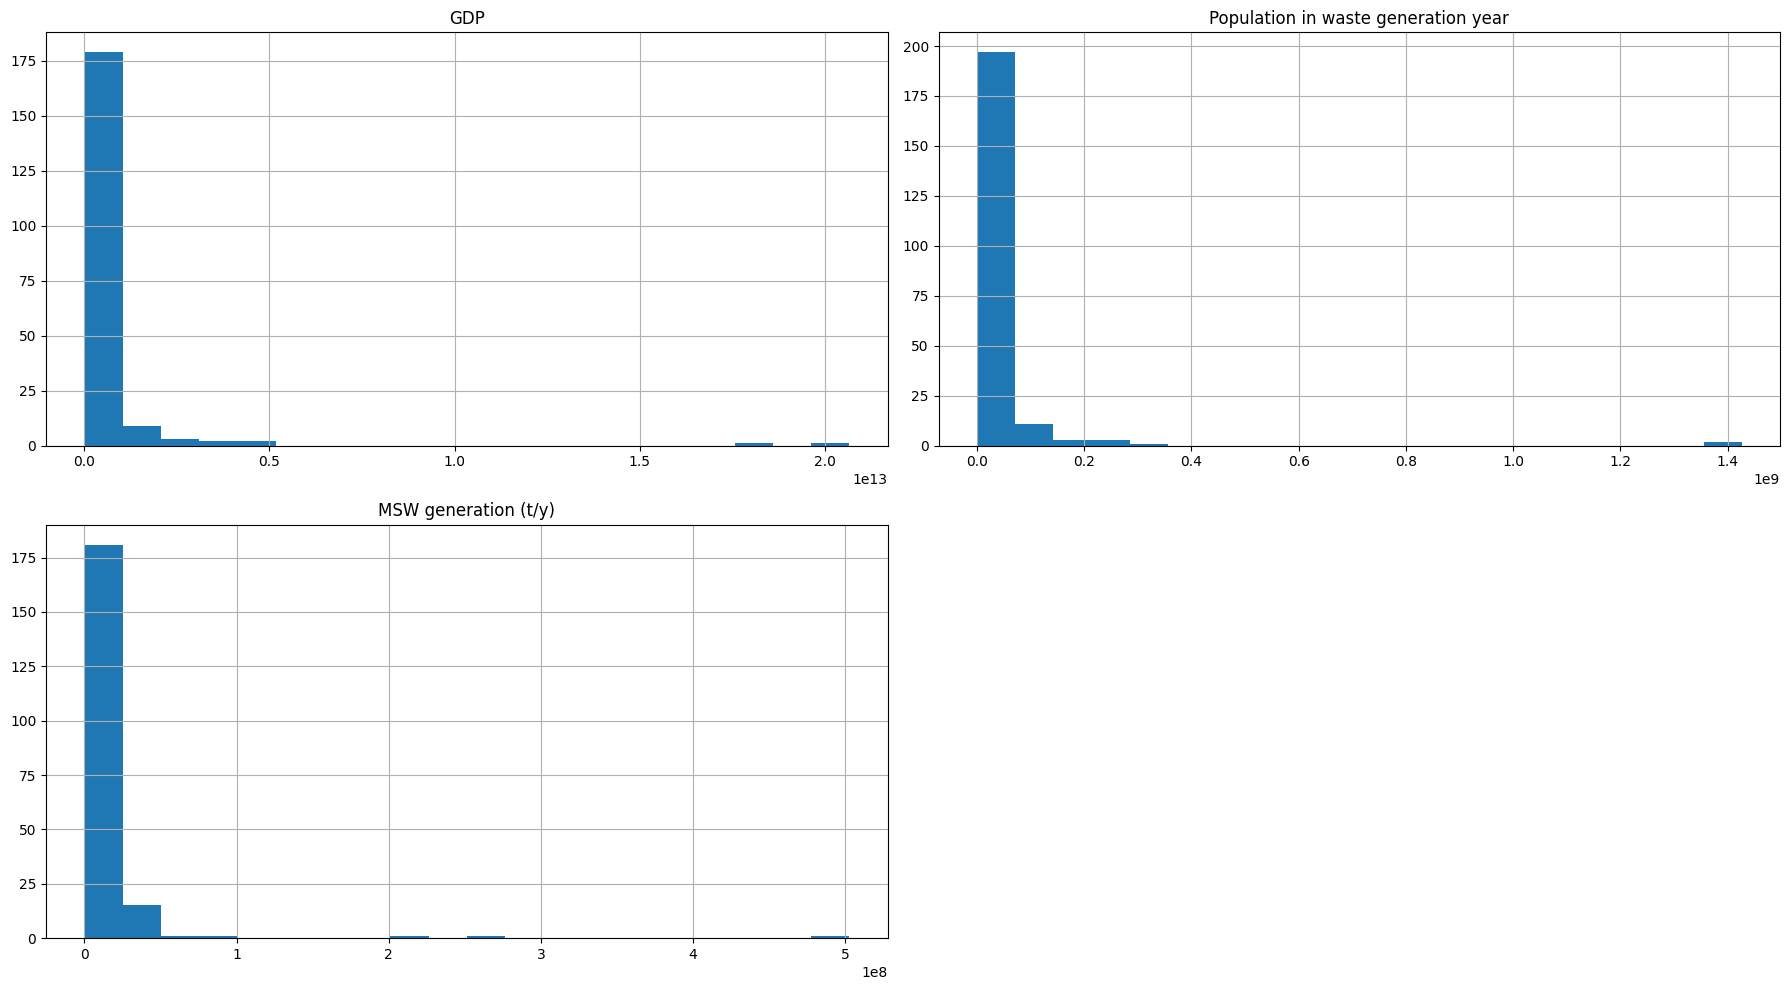

In [25]:
# 1. Remove the first row (technical IDs) and work with a clean copy
df_clean = df.iloc[1:].copy()

# 2. Define the columns we want to analyze
analysis_cols = ['GDP', 'Population in waste generation year', 'MSW generation (t/y)']

# 3. Convert to numeric, removing commas
for col in analysis_cols:
    df_clean[col] = pd.to_numeric(df_clean[col].astype(str).str.replace(',', ''), errors='coerce')

# 4. Plot histograms for the cleaned numerical columns
df_clean[analysis_cols].hist(figsize=(18, 10), bins=20)
plt.tight_layout()
plt.show()

## Correlation

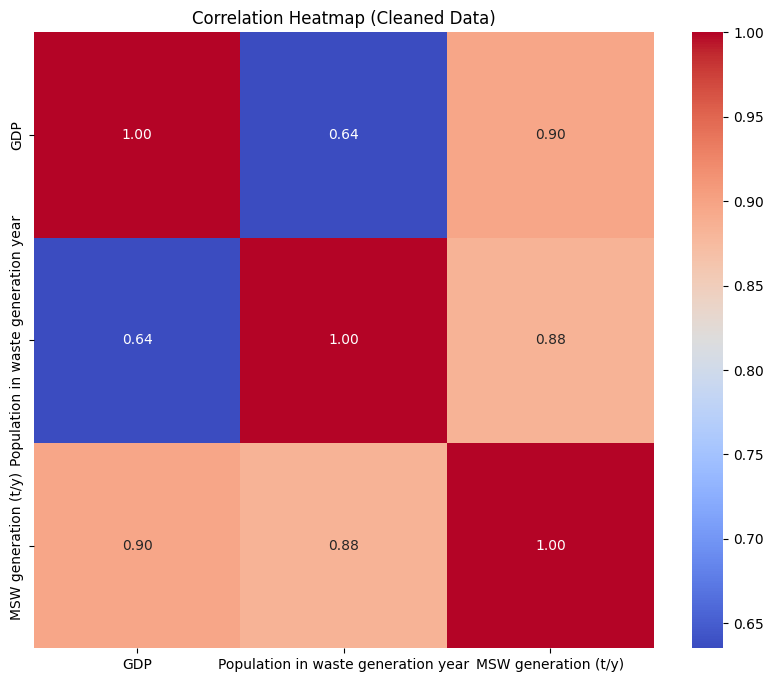

In [27]:
plt.figure(figsize=(10, 8))

# Use df_clean and analysis_cols which were prepared in cell noh9FcOPEnL9
correlation_matrix = df_clean[analysis_cols].corr()

sns.heatmap(correlation_matrix,
            cmap="coolwarm",
            annot=True,
            fmt=".2f")

plt.title("Correlation Heatmap (Cleaned Data)")
plt.show()

## Boxplots (Detect Outliers)

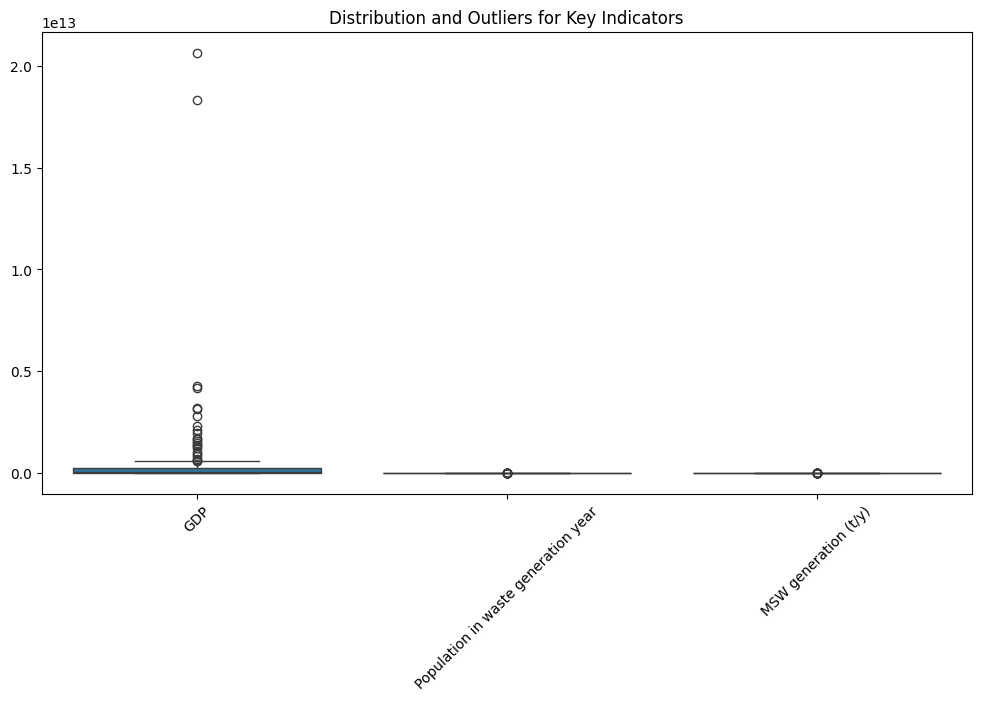

In [30]:
plt.figure(figsize=(12, 6))

# Use the cleaned data and analysis columns
sns.boxplot(data=df_clean[analysis_cols])

plt.title("Distribution and Outliers for Key Indicators")
plt.xticks(rotation=45)
plt.show()

## PairPlot

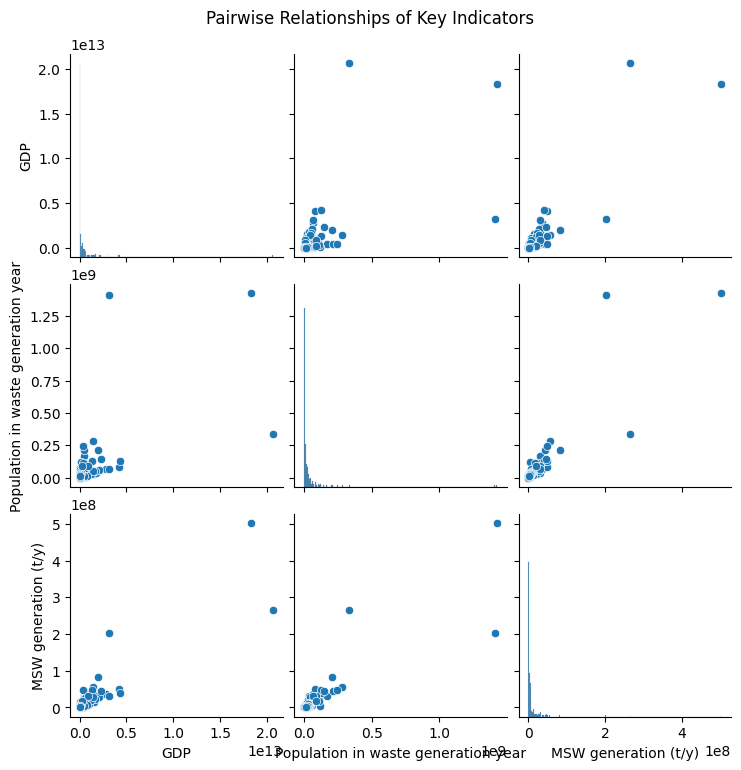

In [32]:
# Use the cleaned data and the analysis columns we identified
sns.pairplot(df_clean[analysis_cols])

plt.suptitle("Pairwise Relationships of Key Indicators", y=1.02)
plt.show()

## Feature Selection

In [33]:
df.columns

Index(['Country code', 'Region', 'Country name ',
       'Income group (waste generation year)', 'Income group (2022)', 'GDP',
       'Population in waste generation year', 'MSW generation - year reported',
       'MSW generation (t/y)', 'MSW generation - point of measurement',
       ...
       'Existence of EPR system for waste batteries',
       'Existence of EPR system for other waste',
       'EPR leadership model (private or government led)',
       'Mandatory or voluntary EPR', 'Operational status of EPR system',
       'Existence of DRS for beverage containers', 'Geographical scope of DRS',
       'DRS container scope', 'Driver of participation in DRS',
       'Operational status of DRS'],
      dtype='object', length=110)

### 1. Feature Selection and Cleaning
We will select meaningful variables and handle missing values by filling them with the median to avoid losing too much data for the clustering.

In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def find_col(substring):
    for c in df_clean.columns:
        if substring.lower() in c.lower() and '%' in c:
            return c
    return None

feature_cols = [
    'Population in waste generation year',
    'GDP',
    'MSW generation (t/y)',
    'Composition - plastic (% weight MSW)',
    'Composition - food  (% weight MSW)',
    'Collection coverage - total (% households)',
    'Treatment - recycling (% weight MSW generated)',
    find_col('landfill'),
    find_col('compost')
]

feature_cols = [c for c in feature_cols if c is not None]
clustering_df = df_clean[feature_cols].copy()

# Rigorous cleaning of non-numeric placeholders
for col in clustering_df.columns:
    # Convert to string, replace dashes and null-strings with NaN, strip commas
    clustering_df[col] = clustering_df[col].astype(str).str.replace(',', '').replace(['—', 'nan', 'None', 'null', ''], np.nan)
    clustering_df[col] = pd.to_numeric(clustering_df[col], errors='coerce')

    # Fill with median; if column is entirely NaN, fill with 0 to prevent downstream errors
    median_val = clustering_df[col].median()
    if pd.isna(median_val):
        clustering_df[col] = clustering_df[col].fillna(0)
    else:
        clustering_df[col] = clustering_df[col].fillna(median_val)

display(clustering_df.head())
print(f"Cleaned data shape: {clustering_df.shape}")

,Population in waste generation year,GDP,MSW generation (t/y),Composition - plastic (% weight MSW),Composition - food (% weight MSW),Collection coverage - total (% households),Treatment - recycling (% weight MSW generated),Treatment - controlled landfill (% weight MSW generated),Treatment - composting (% weight MSW generated)
1,35174083,1.875346e+10,4148162.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2865704,1.803201e+10,754094.0,0.0,0.0,0.0,0.0,0.0,0.0
3,43685420,1.648734e+11,13500000.0,0.0,0.0,0.0,0.0,0.0,0.0
4,50563,6.470000e+08,17348.0,0.0,0.0,0.0,0.0,0.0,0.0
5,77611,3.324648e+09,37950.0,0.0,0.0,0.0,0.0,0.0,0.0


Cleaned data shape: (217, 9)


### 2. Feature Scaling
K-Means is distance-based, so we must scale the data so that a column with large values (like Population) doesn't outweigh a percentage column (like Recycling rate).

In [42]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_df)

# Final safety check: replace any residuals from constant columns with 0
scaled_features = np.nan_to_num(scaled_features)

scaled_df = pd.DataFrame(scaled_features, columns=clustering_df.columns)
display(scaled_df.head())

,Population in waste generation year,GDP,MSW generation (t/y),Composition - plastic (% weight MSW),Composition - food (% weight MSW),Collection coverage - total (% households),Treatment - recycling (% weight MSW generated),Treatment - controlled landfill (% weight MSW generated),Treatment - composting (% weight MSW generated)
0,-0.006171,-0.214466,-0.155857,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.235381,-0.214837,-0.237369,0.0,0.0,0.0,0.0,0.0,0.0
2,0.054212,-0.139392,0.068734,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.255352,-0.223769,-0.255062,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.255160,-0.222393,-0.254567,0.0,0.0,0.0,0.0,0.0,0.0


### 3. Finding the Optimal Number of Clusters
We will use the Elbow Method (sum of squared distances) and the Silhouette Score to determine the best value for $k$.

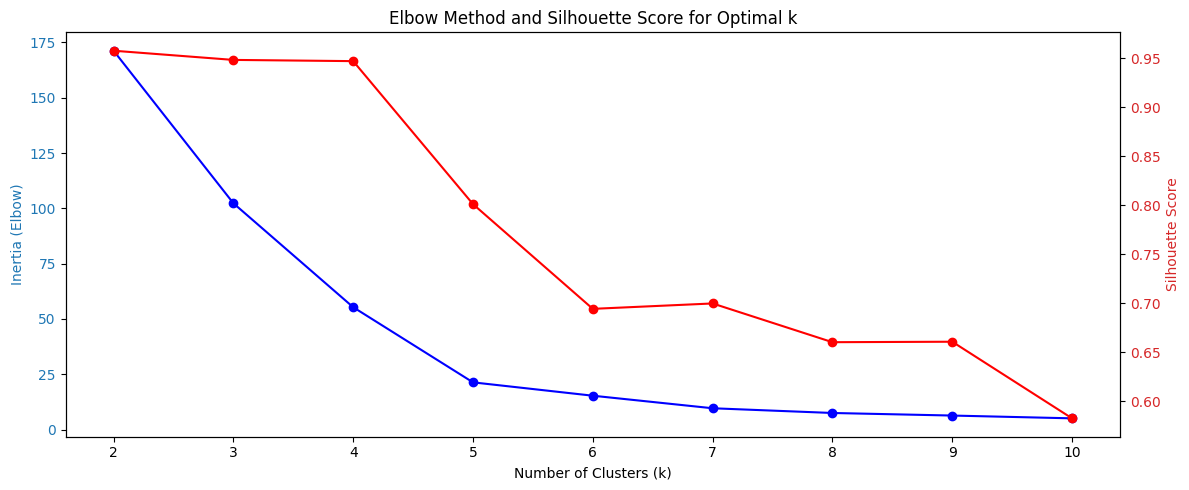

In [43]:
# Final safety check to ensure no NaN or infinite values remain
scaled_features = np.nan_to_num(scaled_features)

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, kmeans.labels_))

# Plotting the Elbow and Silhouette results
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Elbow)', color='tab:blue')
ax1.plot(K_range, inertia, 'bo-')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Elbow Method and Silhouette Score for Optimal k')
fig.tight_layout()
plt.show()

In [44]:
import numpy as np

# Initialize and fit K-Means with k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(scaled_features)

# Add labels back to the cleaned dataframe and original copy
df_clean['Cluster'] = clusters

# Display the first few rows with cluster labels
# We include country name to make the results interpretable
display_cols = ['Country name ', 'GDP', 'Population in waste generation year', 'MSW generation (t/y)', 'Cluster']
display(df_clean[display_cols].head(10))

,Country name,GDP,Population in waste generation year,MSW generation (t/y),Cluster
1,Afghanistan,1.875346e+10,35174083,4148162.0,0
2,Albania,1.803201e+10,2865704,754094.0,0
3,Algeria,1.648734e+11,43685420,13500000.0,0
4,American Samoa,6.470000e+08,50563,17348.0,0
5,Andorra,3.324648e+09,77611,37950.0,0
6,Angola,1.359668e+11,26665959,7786460.0,0
7,Antigua and Barbuda,1.364730e+09,86822,30300.0,0
8,Argentina,6.327901e+11,45356784,19345000.0,0
9,Armenia,1.951351e+10,2859401,532699.0,0
10,Aruba,3.395799e+09,106771,67810.0,0


### 4. Cluster Analysis and Visualization
We will visualize the clusters and look at the mean values of our features for each cluster to interpret the results.

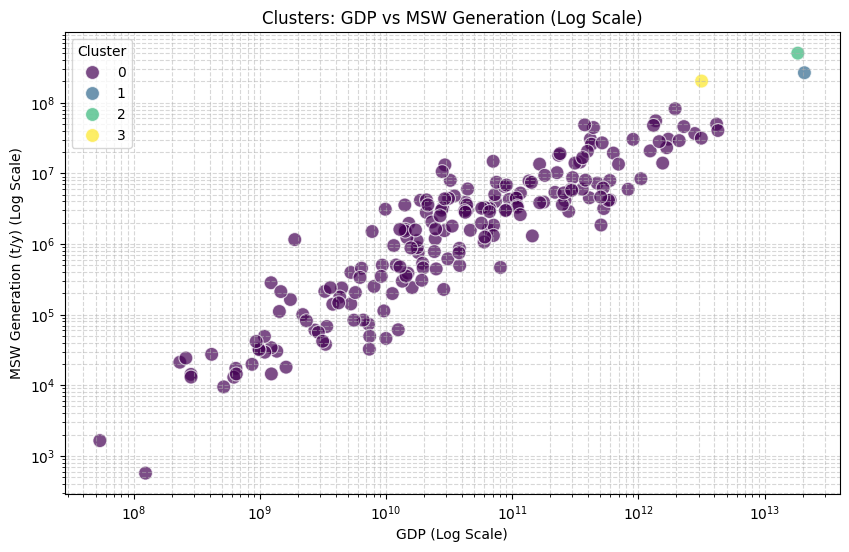

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualize the clusters: GDP vs MSW Generation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='GDP', y='MSW generation (t/y)', hue='Cluster', palette='viridis', s=100, alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.title('Clusters: GDP vs MSW Generation (Log Scale)')
plt.xlabel('GDP (Log Scale)')
plt.ylabel('MSW Generation (t/y) (Log Scale)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(title='Cluster')
plt.show()

In [48]:
# 2. Analyze Cluster Characteristics
# Ensure feature columns are numeric before grouping
for col in feature_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)

# Calculate the mean of numeric features for each cluster
cluster_summary = df_clean.groupby('Cluster')[feature_cols].mean()

print("Average values per Cluster (Interpretation of Groups):")
display(cluster_summary)

Average values per Cluster (Interpretation of Groups):


,Population in waste generation year,GDP,MSW generation (t/y),Composition - plastic (% weight MSW),Composition - food (% weight MSW),Collection coverage - total (% households),Treatment - recycling (% weight MSW generated),Treatment - controlled landfill (% weight MSW generated),Treatment - composting (% weight MSW generated)
Cluster,,,,,,,,,
0,2.174069e+07,2.423525e+11,6.100977e+06,0.0,0.0,0.0,0.0,0.0,0.0
1,3.336753e+08,2.065652e+13,2.652608e+08,0.0,0.0,0.0,0.0,0.0,0.0
2,1.426098e+09,1.831677e+13,5.026074e+08,0.0,0.0,0.0,0.0,0.0,0.0
3,1.409264e+09,3.167271e+12,2.022540e+08,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
import plotly.express as px

# 1. 3D Visualization of the main drivers
fig_3d = px.scatter_3d(
    df_clean,
    x='GDP',
    y='Population in waste generation year',
    z='MSW generation (t/y)',
    color='Cluster',
    hover_name='Country name ',
    log_x=True,
    log_y=True,
    log_z=True,
    title='3D Cluster View: GDP, Population, and Waste (Log Scales)',
    labels={
        'GDP': 'GDP ($)',
        'Population in waste generation year': 'Population',
        'MSW generation (t/y)': 'Waste (t/y)'
    }
)
fig_3d.show()

In [51]:
# 2. Parallel Coordinates Plot to see the profiles across all features
# We normalize for the plot to keep scales comparable
plot_df = clustering_df.copy()
plot_df['Cluster'] = df_clean['Cluster'].values

fig_para = px.parallel_coordinates(
    plot_df,
    color='Cluster',
    labels={col: col[:15] + '...' for col in plot_df.columns},
    title='Cluster Profiles across All Features'
)
fig_para.show()

### 5. Model Evaluation: Silhouette Analysis
The Silhouette Score measures how similar an object is to its own cluster compared to other clusters.

Overall Silhouette Score for k=4: 0.9471


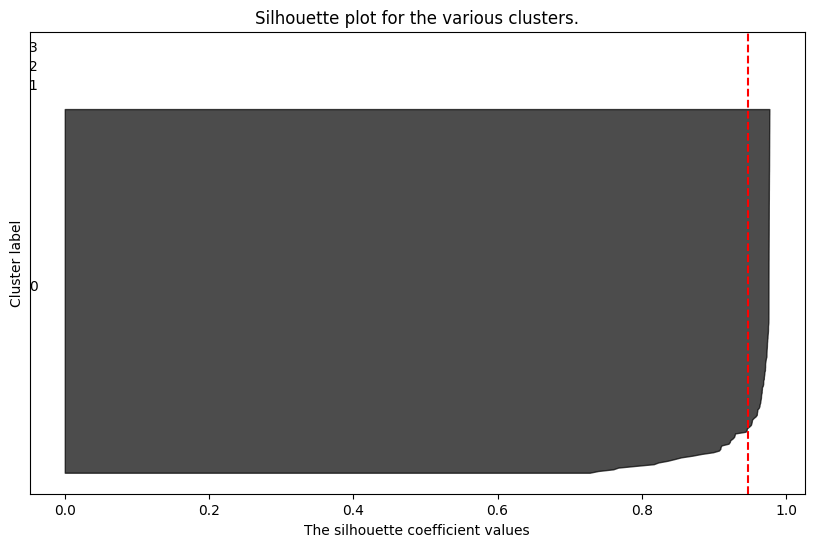

In [49]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

# Calculate the overall silhouette score
score = silhouette_score(scaled_features, clusters)
print(f"Overall Silhouette Score for k=4: {score:.4f}")

# Create a Silhouette Plot
fig, ax1 = plt.subplots(figsize=(10, 6))
sample_silhouette_values = silhouette_samples(scaled_features, clusters)

y_lower = 10
for i in range(4):
    ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / 4)
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax1.set_title("Silhouette plot for the various clusters.")
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
ax1.axvline(x=score, color="red", linestyle="--")
ax1.set_yticks([])  # Clear the yaxis labels / ticks
plt.show()

### **Visualizing Clusters across Scaled Features**
Since we used 9 features for clustering, visualizing them all at once can be difficult. Here, we use a pairplot on the first 7 scaled features to see how the clusters occupy different areas of the feature space.

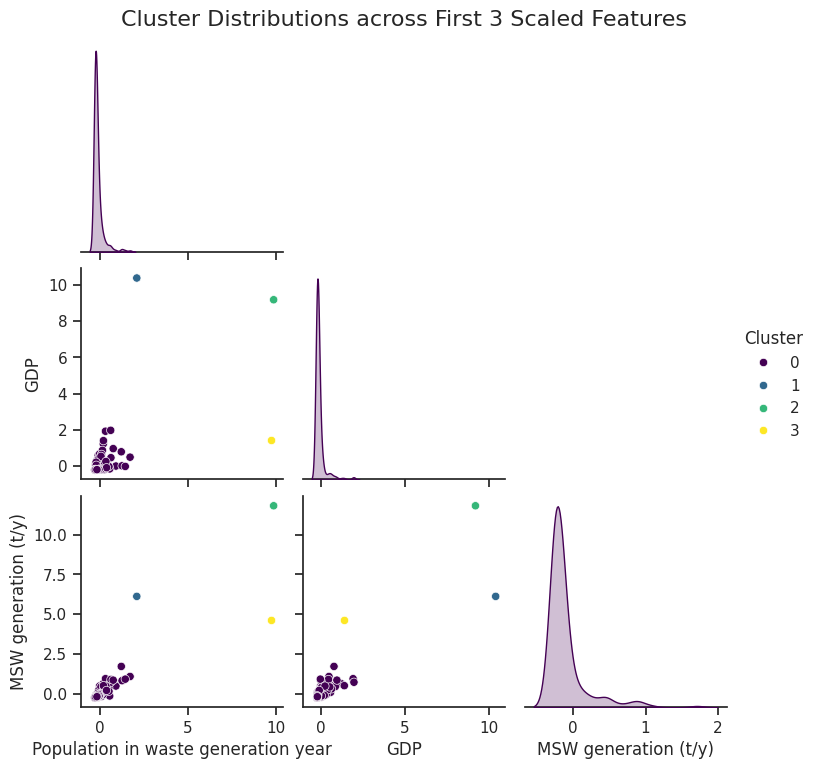

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a dataframe from the first 3 scaled features for visualization
# and add the cluster labels
vis_df = scaled_df.iloc[:, :3].copy()
vis_df['Cluster'] = clusters

# Create the pairplot
sns.set(style="ticks")
g = sns.pairplot(vis_df, hue='Cluster', palette='viridis', corner=True, diag_kind='kde')
g.fig.suptitle('Cluster Distributions across First 3 Scaled Features', y=1.02, fontsize=16)
plt.show()

### **Cluster Analysis: Country Distribution and Feature Means**
We'll now quantify how many countries fall into each cluster and look at the average 'profile' of each group.

In [54]:
# 1. Count the number of countries in each cluster
counts = df_clean['Cluster'].value_counts().sort_index()
print("Number of countries per cluster:")
print(counts)

# 2. Calculate the average values of numerical features for each cluster
# Using the analysis_cols (GDP, Population, MSW generation)
cluster_summary = df_clean.groupby('Cluster')[analysis_cols].mean()

print("\nAverage values per cluster:")
display(cluster_summary)

Number of countries per cluster:
Cluster
0    214
1      1
2      1
3      1
Name: count, dtype: int64

Average values per cluster:


,GDP,Population in waste generation year,MSW generation (t/y)
Cluster,,,
0,2.423525e+11,2.174069e+07,6.100977e+06
1,2.065652e+13,3.336753e+08,2.652608e+08
2,1.831677e+13,1.426098e+09,5.026074e+08
3,3.167271e+12,1.409264e+09,2.022540e+08


### **Identifying the Outlier Countries**
Since Clusters 1, 2, and 3 contain only one country each, let's see which specific nations they represent to better understand the model's logic.

In [55]:
# Identify countries in the outlier clusters
outliers = df_clean[df_clean['Cluster'].isin([1, 2, 3])][['Country name ', 'Cluster', 'GDP', 'Population in waste generation year', 'MSW generation (t/y)']]
print("Identify Outlier Countries:")
display(outliers)

# Interpretation based on means
# Cluster 0: Developing & Developed nations (General)
# Cluster 1: The United States (Highest GDP)
# Cluster 2: China (Highest Waste & Population)
# Cluster 3: India (High Population)


Identify Outlier Countries:


,Country name,Cluster,GDP,Population in waste generation year,MSW generation (t/y)
42,China,2,1.831677e+13,1426098192,502607448.0
90,India,3,3.167271e+12,1409264315,202254010.0
207,United States,1,2.065652e+13,333675290,265260818.0


## Conclusion

This project applied the K-Means Clustering algorithm to the World Bank's "What a Waste 3.0" dataset. After cleaning the data, handling missing values, performing exploratory data analysis, and scaling numerical features, the optimal number of clusters was determined using the Elbow Method. The resulting clusters grouped countries with similar waste management characteristics, providing insights into patterns of waste generation, recycling, and disposal. The Silhouette Score was used to evaluate the quality of the clustering, indicating how well-separated the clusters were. This analysis demonstrates how unsupervised machine learning can support sustainability and green skill initiatives by identifying similarities in waste management practices across countries.